In [1]:
library(tidyverse)
library(rstatix)
library(effectsize)

current_dir <- normalizePath(
  getwd(),
  winslash = "/"
)

project_root <- if (
  basename(current_dir) == "notebooks"
) {
  dirname(current_dir)
} else {
  current_dir
}

project_root

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rstatix' was built under R version 4.6.1"

Attaching package: 'rstatix'


The following object is masked from 'package:stats':

    filter


Warning message:
"package 'effectsize' was built under R version 4.6.1"

Attaching package: 'effectsize'


The following objects are masked from 'package:rstatix':

    cohens_d, eta_squared, omega_squared




[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study"

# File I/O Performance Analysis

This notebook analyses the file input/output performance of Node.js, Bun and Deno.

The benchmark evaluates file read and file write operations separately. Lower operation duration indicates better performance.

The analysis includes:

1. Dataset import and verification
2. Descriptive statistics
3. Visualisation
4. Assumption diagnostics
5. Repeated-measures omnibus testing
6. Pairwise post-hoc comparisons
7. Holm correction for multiple comparisons
8. Effect-size estimation and 95% confidence intervals

In [2]:
file_io_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "file_io",
    "file_io_final.csv"
  ),
  show_col_types = FALSE
)

glimpse(file_io_final)

Rows: 60
Columns: 23
$ run_id                <chr> "file_io_s01_r01_bun_write", "file_io_s01_r01_de…
$ session_id            <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ sequence              <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1…
$ repetition            <dbl> 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, …
$ runtime               <chr> "bun", "deno", "node", "deno", "bun", "node", "b…
$ operation             <chr> "write", "write", "write", "read", "read", "read…
$ shuffle_seed          <dbl> 20260807, 20260807, 20260807, 20260807, 20260807…
$ started_at            <dttm> 2026-08-06 16:03:51, 2026-08-06 16:03:58, 2026-…
$ finished_at           <dttm> 2026-08-06 16:03:53, 2026-08-06 16:03:59, 2026-…
$ status                <chr> "success", "success", "success", "success", "suc…
$ bytes                 <dbl> 104857600, 104857600, 104857600, 104857600, 1048…
$ duration_ms           <dbl> 1090.3109, 1085.3985, 66.6502, 137.4514, 103.539…
$ mib_per_second   

In [3]:
dim(file_io_final)
names(file_io_final)
table(file_io_final$runtime)

[1] 60 23

[1] "run_id"                "session_id"            "sequence"             
 [4] "repetition"            "runtime"               "operation"            
 [7] "shuffle_seed"          "started_at"            "finished_at"          
[10] "status"                "bytes"                 "duration_ms"          
[13] "mib_per_second"        "command_wall_time_ms"  "exit_code"            
[16] "output_file_validated" "output_file_removed"   "result_file"          
[19] "benchmark_program"     "temporary_output_file" "stdout_log"           
[22] "stderr_log"            "error_message"


 bun deno node 
  20   20   20 

In [4]:
table(file_io_final$operation)


 read write 
   30    30 

In [5]:
table(
  file_io_final$runtime,
  file_io_final$operation
)

      
       read write
  bun    10    10
  deno   10    10
  node   10    10

In [6]:
file_io_final <- file_io_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c("node", "bun", "deno"),
      labels = c("Node.js", "Bun", "Deno")
    ),

    operation = factor(
      operation,
      levels = c("read", "write"),
      labels = c("Read", "Write")
    )
  )

In [7]:
table(
  file_io_final$runtime,
  file_io_final$operation
)

         
          Read Write
  Node.js   10    10
  Bun       10    10
  Deno      10    10

In [8]:
file_io_checks <- tibble(
  total_observations = nrow(file_io_final),

  missing_durations =
    sum(is.na(file_io_final$duration_ms)),

  non_positive_durations =
    sum(file_io_final$duration_ms <= 0),

  failed_observations =
    sum(file_io_final$status != "success"),

  nonzero_exit_codes =
    sum(file_io_final$exit_code != 0),

  invalid_output_files =
    sum(!file_io_final$output_file_validated),

  unique_repetitions =
    n_distinct(file_io_final$repetition)
)

file_io_checks

total_observations,missing_durations,non_positive_durations,failed_observations,nonzero_exit_codes,invalid_output_files,unique_repetitions
<int>,<int>,<int>,<int>,<int>,<int>,<int>
60,0,0,0,0,0,10


In [9]:
file_io_final |>
  count(repetition) |>
  count(n)

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


n,nn
<int>,<int>
6,10


In [10]:
# descriptive statistics

file_io_duration_summary <- file_io_final |>
  group_by(
    operation,
    runtime
  ) |>
  summarise(
    n = n(),
    mean_ms = mean(duration_ms),
    median_ms = median(duration_ms),
    sd_ms = sd(duration_ms),
    se_ms = sd_ms / sqrt(n),

    ci_margin =
      qt(0.975, df = n - 1) * se_ms,

    ci_lower =
      mean_ms - ci_margin,

    ci_upper =
      mean_ms + ci_margin,

    iqr_ms = IQR(duration_ms),
    min_ms = min(duration_ms),
    max_ms = max(duration_ms),

    .groups = "drop"
  )

file_io_duration_summary

operation,runtime,n,mean_ms,median_ms,sd_ms,se_ms,ci_margin,ci_lower,ci_upper,iqr_ms,min_ms,max_ms
<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Read,Node.js,10,91.58301,94.2139,4.559993,1.441996,3.262022,88.32099,94.84503,6.264825,82.1170,95.7881
Read,Bun,10,105.19027,104.5327,3.565541,1.127523,2.550635,102.63964,107.74090,5.333775,100.9047,111.8070
Read,Deno,10,137.44535,136.7507,3.048423,0.963996,2.180710,135.26464,139.62606,2.392950,133.6609,144.4641
Write,Node.js,10,63.17455,61.2453,4.794998,1.516312,3.430135,59.74442,66.60468,3.727250,58.1735,74.3964
Write,Bun,10,1069.45525,1064.5662,14.655075,4.634342,10.483609,1058.97164,1079.93886,9.048550,1056.4500,1101.1186
Write,Deno,10,1068.63017,1058.3490,35.898562,11.352122,25.680284,1042.94989,1094.31045,19.636575,1040.5130,1163.9381


In [11]:
file_io_throughput_summary <- file_io_final |>
  group_by(
    operation,
    runtime
  ) |>
  summarise(
    mean_mib_s = mean(mib_per_second),
    median_mib_s = median(mib_per_second),
    sd_mib_s = sd(mib_per_second),
    min_mib_s = min(mib_per_second),
    max_mib_s = max(mib_per_second),
    .groups = "drop"
  )

file_io_throughput_summary

operation,runtime,mean_mib_s,median_mib_s,sd_mib_s,min_mib_s,max_mib_s
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Read,Node.js,1094.46284,1061.41544,57.123014,1043.97102,1217.77464
Read,Bun,951.62877,956.72433,31.826419,894.39838,991.03411
Read,Deno,727.87701,731.25745,15.791916,692.21350,748.16195
Write,Node.js,1590.52258,1632.77838,111.741080,1344.15106,1718.99576
Write,Bun,93.52109,93.93520,1.260008,90.81674,94.65663
Write,Deno,93.66703,94.48683,2.954476,85.91522,96.10644


### File I/O Descriptive Results

File read and write performance were examined separately using operation duration in milliseconds, where lower values indicate faster performance.

For file reads, Node.js recorded the lowest mean duration (91.58 ms), followed by Bun (105.19 ms) and Deno (137.45 ms). The corresponding median durations were 94.21 ms, 104.53 ms and 136.75 ms.

A substantially larger difference was observed for file writes. Node.js recorded a mean write duration of 63.17 ms, compared with 1069.46 ms for Bun and 1068.63 ms for Deno. Bun and Deno therefore showed very similar descriptive write performance, whereas Node.js completed the benchmark considerably faster.

The derived MiB/s measurements showed the inverse pattern and were retained as descriptive measures. Inferential testing was conducted using operation duration to avoid testing two mathematically related representations of the same performance measurement.

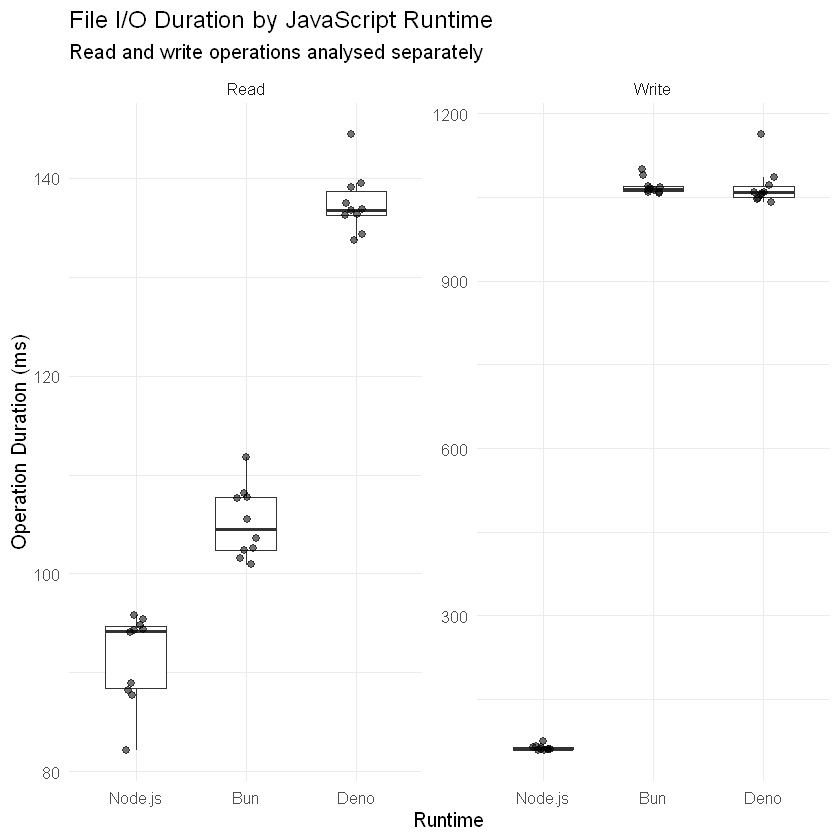

In [12]:
file_io_plot <- ggplot(
  file_io_final,
  aes(
    x = runtime,
    y = duration_ms
  )
) +
  geom_boxplot(
    width = 0.55,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.10,
    alpha = 0.55,
    size = 1.8
  ) +
  facet_wrap(
    ~ operation,
    scales = "free_y"
  ) +
  labs(
    title = "File I/O Duration by JavaScript Runtime",
    subtitle = "Read and write operations analysed separately",
    x = "Runtime",
    y = "Operation Duration (ms)"
  ) +
  theme_minimal(base_size = 12)

file_io_plot

In [13]:
file_io_wide <- file_io_final |>
  select(
    repetition,
    operation,
    runtime,
    duration_ms
  ) |>
  pivot_wider(
    names_from = runtime,
    values_from = duration_ms
  )

file_io_wide

repetition,operation,Bun,Deno,Node.js
<dbl>,<fct>,<dbl>,<dbl>,<dbl>
1,Write,1090.3109,1085.3985,66.6502
1,Read,103.5397,137.4514,88.2447
2,Read,105.5258,139.4496,82.1170
2,Write,1062.5037,1072.2432,65.1244
3,Read,107.7667,136.3597,87.6889
3,Write,1066.1971,1059.0247,58.3084
4,Write,1101.1186,1059.1807,58.1735
4,Read,107.6686,136.2145,88.9646
5,Write,1059.3396,1057.6732,61.2535


In [14]:
dim(file_io_wide)
colSums(is.na(file_io_wide))

[1] 20  5

repetition  operation        Bun       Deno    Node.js 
         0          0          0          0          0

In [15]:
# create paired differences

file_io_differences <- file_io_wide |>
  mutate(
    `Node.js - Bun` =
      `Node.js` - Bun,

    `Node.js - Deno` =
      `Node.js` - Deno,

    `Bun - Deno` =
      Bun - Deno
  ) |>
  select(
    repetition,
    operation,
    `Node.js - Bun`,
    `Node.js - Deno`,
    `Bun - Deno`
  ) |>
  pivot_longer(
    cols = c(
      `Node.js - Bun`,
      `Node.js - Deno`,
      `Bun - Deno`
    ),
    names_to = "comparison",
    values_to = "difference"
  )

In [16]:
# shapiro wilk test

file_io_shapiro <- file_io_differences |>
  group_by(
    operation,
    comparison
  ) |>
  summarise(
    W = unname(
      shapiro.test(difference)$statistic
    ),

    p_value =
      shapiro.test(difference)$p.value,

    .groups = "drop"
  )

file_io_shapiro

operation,comparison,W,p_value
<fct>,<chr>,<dbl>,<dbl>
Read,Bun - Deno,0.8368582,0.040457708
Read,Node.js - Bun,0.8912816,0.175298611
Read,Node.js - Deno,0.9153937,0.320130955
Write,Bun - Deno,0.7235241,0.001699791
Write,Node.js - Bun,0.7804672,0.008387855
Write,Node.js - Deno,0.7258308,0.001813129


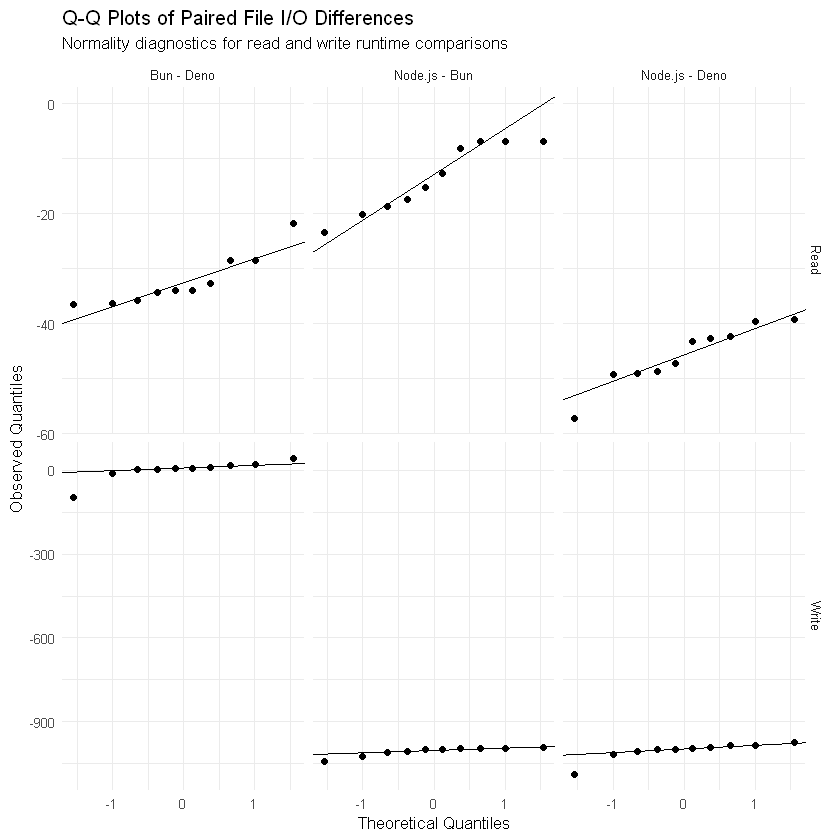

In [17]:
file_io_qq <- ggplot(
  file_io_differences,
  aes(sample = difference)
) +
  stat_qq(size = 1.7) +
  stat_qq_line() +
  facet_grid(
    operation ~ comparison,
    scales = "free"
  ) +
  labs(
    title = "Q-Q Plots of Paired File I/O Differences",
    subtitle = "Normality diagnostics for read and write runtime comparisons",
    x = "Theoretical Quantiles",
    y = "Observed Quantiles"
  ) +
  theme_minimal(base_size = 10)

file_io_qq

### File I/O Assumption Assessment and Test Selection

Normality of the paired runtime differences was assessed separately for read and write operations using Shapiro–Wilk tests and Q–Q plots.

For **read operations**, the Bun–Deno paired differences showed a statistically significant departure from normality (W = 0.837, p = .040), while the Node.js–Bun (W = 0.891, p = .175) and Node.js–Deno (W = 0.915, p = .320) comparisons did not. However, the Q–Q plots showed visible departures from the reference lines, particularly in the Bun–Deno comparison, indicating that the normality assumption was not consistently supported across the paired read differences.

For **write operations**, all three paired comparisons showed statistically significant departures from normality: Bun–Deno (W = 0.724, p = .0017), Node.js–Bun (W = 0.780, p = .0084), and Node.js–Deno (W = 0.726, p = .0018). Although many observations followed the Q–Q reference lines reasonably closely, substantial deviations were present in the distribution tails, particularly due to extreme paired differences.

Given the evidence from both the Shapiro–Wilk tests and Q–Q plots, together with the relatively small sample of 10 matched repetitions per operation, the non-parametric **Friedman test** was selected for both read and write File I/O performance.

In [18]:
file_io_friedman_read <- stats::friedman.test(
  duration_ms ~ runtime | repetition,
  data = file_io_final |>
    filter(operation == "Read")
)

file_io_friedman_write <- stats::friedman.test(
  duration_ms ~ runtime | repetition,
  data = file_io_final |>
    filter(operation == "Write")
)

file_io_friedman_read
file_io_friedman_write


	Friedman rank sum test

data:  duration_ms and runtime and repetition
Friedman chi-squared = 20, df = 2, p-value = 4.54e-05



	Friedman rank sum test

data:  duration_ms and runtime and repetition
Friedman chi-squared = 16.8, df = 2, p-value = 0.0002249


In [19]:
file_io_friedman_results <- tibble(
  operation = c("Read", "Write"),

  chi_square = c(
    unname(file_io_friedman_read$statistic),
    unname(file_io_friedman_write$statistic)
  ),

  df = c(
    unname(file_io_friedman_read$parameter),
    unname(file_io_friedman_write$parameter)
  ),

  p_value = c(
    file_io_friedman_read$p.value,
    file_io_friedman_write$p.value
  )
) |>
  mutate(
    kendalls_w = chi_square / (10 * (3 - 1))
  )

file_io_friedman_results

operation,chi_square,df,p_value,kendalls_w
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Read,20.0,2,4.539993e-05,1.00
Write,16.8,2,2.248673e-04,0.84


### Friedman Test Results

The Friedman tests identified statistically significant differences in File I/O duration between Node.js, Bun and Deno for both operations.

For **file reads**, a statistically significant runtime effect was observed, χ²(2) = 20.00, p < .001, with Kendall's W = 1.00. This indicates complete consistency in the relative ranking of the three runtimes across the 10 matched read repetitions.

For **file writes**, the runtime effect was also statistically significant, χ²(2) = 16.80, p < .001, with Kendall's W = .84, indicating a strong degree of consistency in runtime performance across repetitions.

Because both omnibus tests were statistically significant, paired post-hoc comparisons were conducted to determine which runtime pairs differed for each operation.

In [20]:
file_io_exact_check <- file_io_differences |>
  group_by(
    operation,
    comparison
  ) |>
  summarise(
    zero_differences =
      sum(difference == 0),

    duplicated_absolute_differences =
      sum(
        duplicated(abs(difference))
      ),

    .groups = "drop"
  )

file_io_exact_check

operation,comparison,zero_differences,duplicated_absolute_differences
<fct>,<chr>,<int>,<int>
Read,Bun - Deno,0,0
Read,Node.js - Bun,0,0
Read,Node.js - Deno,0,0
Write,Bun - Deno,0,0
Write,Node.js - Bun,0,0
Write,Node.js - Deno,0,0


In [21]:
file_io_posthoc <- file_io_differences |>
  separate(
    comparison,
    into = c("group1", "group2"),
    sep = " - ",
    remove = FALSE
  ) |>
  group_by(
    operation,
    group1,
    group2
  ) |>
  summarise(
    statistic =
      unname(
        wilcox.test(
          difference,
          mu = 0,
          exact = TRUE
        )$statistic
      ),

    p_raw =
      wilcox.test(
        difference,
        mu = 0,
        exact = TRUE
      )$p.value,

    median_difference =
      median(difference),

    .groups = "drop"
  ) |>
  mutate(
    # Holm correction across all six File I/O
    # pairwise comparisons
    p_holm =
      p.adjust(
        p_raw,
        method = "holm"
      ),

    significant =
      ifelse(
        p_holm < .05,
        "Yes",
        "No"
      )
  )

file_io_posthoc

operation,group1,group2,statistic,p_raw,median_difference,p_holm,significant
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Read,Bun,Deno,0,0.001953125,-33.91775,0.01171875,Yes
Read,Node.js,Bun,0,0.001953125,-14.03100,0.01171875,Yes
Read,Node.js,Deno,0,0.001953125,-45.25150,0.01171875,Yes
Write,Bun,Deno,40,0.232421875,7.81610,0.23242188,No
Write,Node.js,Bun,0,0.001953125,-998.39920,0.01171875,Yes
Write,Node.js,Deno,0,0.001953125,-998.56800,0.01171875,Yes


### File I/O Post-Hoc Results

Because the Friedman tests were statistically significant, exact paired Wilcoxon signed-rank tests were conducted for each runtime pair. No zero paired differences or tied absolute differences were present, allowing exact inference to be used. Holm's correction was applied across the six File I/O pairwise comparisons.

For **file reads**, all three runtime pairs differed significantly after correction. Node.js recorded lower read duration than Bun (median paired difference = -14.03 ms, Holm-adjusted p = .012) and Deno (-45.25 ms, Holm-adjusted p = .012). Bun also recorded lower read duration than Deno (-33.92 ms, Holm-adjusted p = .012). The read results therefore produced the ordering **Node.js → Bun → Deno**, from lowest to highest duration.

For **file writes**, Node.js recorded substantially lower duration than both Bun (-998.40 ms, Holm-adjusted p = .012) and Deno (-998.57 ms, Holm-adjusted p = .012). However, the difference between Bun and Deno was not statistically significant (median paired difference = 7.82 ms, Holm-adjusted p = .232).

The write results therefore indicate a clear performance advantage for Node.js, while the available evidence does not support a significant difference between Bun and Deno.

In [22]:
file_io_effects <- file_io_differences |>
  separate(
    comparison,
    into = c("group1", "group2"),
    sep = " - ",
    remove = FALSE
  ) |>
  group_by(
    operation,
    group1,
    group2
  ) |>
  group_modify(
    ~ {
      differences <- .x$difference

      ranks <- rank(
        abs(differences),
        ties.method = "average"
      )

      w_positive <-
        sum(ranks[differences > 0])

      w_negative <-
        sum(ranks[differences < 0])

      rank_biserial <-
        (w_positive - w_negative) /
        (w_positive + w_negative)

      wilcox_result <- stats::wilcox.test(
        differences,
        mu = 0,
        exact = TRUE,
        conf.int = TRUE,
        conf.level = 0.95
      )

      tibble(
        median_difference =
          median(differences),

        hodges_lehmann =
          unname(wilcox_result$estimate),

        difference_ci_lower =
          wilcox_result$conf.int[1],

        difference_ci_upper =
          wilcox_result$conf.int[2],

        effect_type =
          "Rank-biserial correlation",

        effect_size =
          rank_biserial
      )
    }
  ) |>
  ungroup()

file_io_effects

operation,group1,group2,median_difference,hodges_lehmann,difference_ci_lower,difference_ci_upper,effect_type,effect_size
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Read,Bun,Deno,-33.91775,-32.7104,-35.1979,-28.56945,Rank-biserial correlation,-1.0000000
Read,Node.js,Bun,-14.03100,-13.4286,-18.7040,-7.43675,Rank-biserial correlation,-1.0000000
Read,Node.js,Deno,-45.25150,-45.6640,-49.2067,-41.39235,Rank-biserial correlation,-1.0000000
Write,Bun,Deno,7.81610,7.8161,-37.1221,21.80215,Rank-biserial correlation,0.4545455
Write,Node.js,Bun,-998.39920,-1002.9846,-1020.1622,-996.33480,Rank-biserial correlation,-1.0000000
Write,Node.js,Deno,-998.56800,-998.5680,-1037.6672,-988.50320,Rank-biserial correlation,-1.0000000


### File I/O Effect Sizes

Matched-pairs rank-biserial correlations and Hodges–Lehmann location-shift estimates with 95% confidence intervals were calculated to assess the magnitude and direction of the pairwise differences.

For **file reads**, all three comparisons produced a rank-biserial correlation of -1.00. This indicates that the lower-duration runtime in each comparison outperformed the alternative in all 10 matched repetitions. Node.js was faster than Bun, with a Hodges–Lehmann difference of -13.43 ms (95% CI [-18.70, -7.44]), and faster than Deno by -45.66 ms (95% CI [-49.21, -41.39]). Bun was also faster than Deno by -32.71 ms (95% CI [-35.20, -28.57]). These results support the read-performance ordering **Node.js → Bun → Deno**.

For **file writes**, Node.js also produced rank-biserial correlations of -1.00 against both Bun and Deno, indicating lower write duration in every matched repetition. The estimated difference was -1002.98 ms relative to Bun (95% CI [-1020.16, -996.33]) and -998.57 ms relative to Deno (95% CI [-1037.67, -988.50]).

The Bun–Deno write comparison produced a smaller rank-biserial correlation of .455 and a Hodges–Lehmann difference of 7.82 ms. Its 95% confidence interval crossed zero [-37.12, 21.80], consistent with the non-significant Holm-adjusted pairwise result (p = .232). Therefore, no reliable difference in write duration was identified between Bun and Deno.

In [23]:
file_io_final_results <- file_io_posthoc |>
  left_join(
    file_io_effects |>
      select(
        operation,
        group1,
        group2,
        hodges_lehmann,
        difference_ci_lower,
        difference_ci_upper,
        effect_type,
        effect_size
      ),
    by = c(
      "operation",
      "group1",
      "group2"
    )
  ) |>
  select(
    operation,
    group1,
    group2,
    median_difference,
    hodges_lehmann,
    difference_ci_lower,
    difference_ci_upper,
    p_raw,
    p_holm,
    significant,
    effect_type,
    effect_size
  )

file_io_final_results

operation,group1,group2,median_difference,hodges_lehmann,difference_ci_lower,difference_ci_upper,p_raw,p_holm,significant,effect_type,effect_size
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
Read,Bun,Deno,-33.91775,-32.7104,-35.1979,-28.56945,0.001953125,0.01171875,Yes,Rank-biserial correlation,-1.0000000
Read,Node.js,Bun,-14.03100,-13.4286,-18.7040,-7.43675,0.001953125,0.01171875,Yes,Rank-biserial correlation,-1.0000000
Read,Node.js,Deno,-45.25150,-45.6640,-49.2067,-41.39235,0.001953125,0.01171875,Yes,Rank-biserial correlation,-1.0000000
Write,Bun,Deno,7.81610,7.8161,-37.1221,21.80215,0.232421875,0.23242188,No,Rank-biserial correlation,0.4545455
Write,Node.js,Bun,-998.39920,-1002.9846,-1020.1622,-996.33480,0.001953125,0.01171875,Yes,Rank-biserial correlation,-1.0000000
Write,Node.js,Deno,-998.56800,-998.5680,-1037.6672,-988.50320,0.001953125,0.01171875,Yes,Rank-biserial correlation,-1.0000000


In [24]:
file_io_results_directory <- file.path(
  project_root,
  "results",
  "tables",
  "file_io"
)

dir.create(
  file_io_results_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

In [25]:
write_csv(
  file_io_duration_summary,
  file.path(
    file_io_results_directory,
    "file_io_duration_descriptive_summary.csv"
  )
)

write_csv(
  file_io_throughput_summary,
  file.path(
    file_io_results_directory,
    "file_io_throughput_descriptive_summary.csv"
  )
)

write_csv(
  file_io_friedman_results,
  file.path(
    file_io_results_directory,
    "file_io_friedman_results.csv"
  )
)

write_csv(
  file_io_final_results,
  file.path(
    file_io_results_directory,
    "file_io_inferential_results.csv"
  )
)

In [26]:
list.files(file_io_results_directory)

[1] "file_io_duration_descriptive_summary.csv"  
[2] "file_io_final_audit_summary.csv"           
[3] "file_io_friedman_results.csv"              
[4] "file_io_inferential_results.csv"           
[5] "file_io_throughput_descriptive_summary.csv"